In [1]:
# # Self-Supervised Learning: A Data-Centric Solution for Small Data
# 
# ## Using the MNIST Dataset
# 
# ### What is Self-Supervised Learning?
# 
# Self-supervised learning is a technique where we **create a "pretext task"** from unlabeled data itself. The model learns useful representations by solving this task, without needing any human labels.
# 
# ### The Two-Phase Process:
# 
# 1. **Pre-training Phase (Free!):**
#    - We take a large unlabeled dataset (e.g., all of MNIST).
#    - We create a pretext task where the "label" comes from the data itself.
#    - The model learns to solve this task, building useful features.
#    - **No human labels required!**
# 
# 2. **Fine-tuning Phase (Cheap!):**
#    - We take the pre-trained model.
#    - We adapt it to our specific task (e.g., digit classification).
#    - We only need a small labeled dataset (e.g., 100 samples).
# 
# ### Why Does This Help?
# 
# - The model learns general features from abundant unlabeled data.
# - It starts with a "head start" when we fine-tune.
# - We need very few labeled samples to achieve good performance.
# 
# ### Key Question:
# **How much does SSL pre-training improve performance when we have very few labeled samples?**

# ## 1. Setup and Imports
# 
# We import the necessary libraries:
# - **PyTorch**: For building and training neural networks.
# - **sklearn**: For data loading, metrics, and t-SNE visualization.
# - **matplotlib**: For plotting.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries loaded successfully!")
print(f"PyTorch version: {torch.__version__}")

Libraries loaded successfully!
PyTorch version: 2.5.1


In [3]:
# ## 2. Load and Prepare MNIST Dataset
# 
# We load MNIST and normalize pixel values to [0, 1]. We use the full dataset for SSL pre-training.

# %%
# Load MNIST (full dataset)
print("Loading MNIST dataset...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='pandas')

# Convert to appropriate types
X = X.astype(np.float32)
y = y.astype(np.int32)

# Normalize pixel values to [0, 1]
X = X / 255.0

print(f"Dataset shape: X: {X.shape}, y: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

# %% [markdown]
# ## 3. Split Data: Train, Unlabeled, and Test
# 
# We create three sets:
# - **Unlabeled Pool (60,000 samples)**: Used for SSL pre-training (no labels needed!).
# - **Small Labeled Set (100 samples)**: Used for fine-tuning (10 samples per class).
# - **Test Set (21,000 samples)**: Used for final evaluation.

# Split into train (70%) and test (30%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train_full.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# We will use ALL training data as unlabeled for SSL pre-training
# And a small subset as labeled for fine-tuning

Loading MNIST dataset...
Dataset shape: X: (70000, 784), y: (70000,)
Number of classes: 10
Training set: 49000 samples
Test set: 21000 samples


In [5]:
# ## 4. Create Small Labeled Dataset (for Fine-Tuning)
# 
# We create a very small labeled dataset (100 samples, 10 per class). This simulates the "small data" scenario where labeling is expensive.

def get_small_labeled_dataset(X_train, y_train, n_samples_per_class=10, random_seed=42):
    """
    Get a small balanced labeled dataset.
    
    Parameters:
    - X_train: Full training features
    - y_train: Full training labels
    - n_samples_per_class: Number of samples per class
    - random_seed: Random seed for reproducibility
    
    Returns:
    - X_labeled: Small labeled features
    - y_labeled: Small labeled labels
    - labeled_indices: Indices of selected samples (to exclude from unlabeled pool)
    """
    np.random.seed(random_seed)
    labeled_indices = []
    for class_label in range(10):
        class_indices = np.where(y_train == class_label)[0]
        n_to_sample = min(n_samples_per_class, len(class_indices))
        selected = np.random.choice(class_indices, size=n_to_sample, replace=False)
        labeled_indices.extend(selected)
    
    X_labeled = X_train[labeled_indices]
    y_labeled = y_train[labeled_indices]
    
    return X_labeled, y_labeled, labeled_indices

# Number of labeled samples per class
N_SAMPLES_PER_CLASS = 10  # 10 samples per class = 100 total

# Get small labeled dataset
X_labeled, y_labeled, labeled_indices = get_small_labeled_dataset(
    X_train_full, y_train_full, 
    n_samples_per_class=N_SAMPLES_PER_CLASS, 
    random_seed=42
)

# Create unlabeled pool (everything EXCEPT the labeled samples)
unlabeled_mask = np.ones(len(X_train_full), dtype=bool)
unlabeled_mask[labeled_indices] = False
X_unlabeled = X_train_full[unlabeled_mask]
y_unlabeled_true = y_train_full[unlabeled_mask]  # We keep true labels for evaluation only

print(f"Labeled data: {len(X_labeled)} samples ({N_SAMPLES_PER_CLASS} per class)")
print(f"Unlabeled data: {len(X_unlabeled)} samples (used for SSL pre-training)")
print(f"Test data: {len(X_test)} samples")

Labeled data: 100 samples (10 per class)
Unlabeled data: 48900 samples (used for SSL pre-training)
Test data: 21000 samples


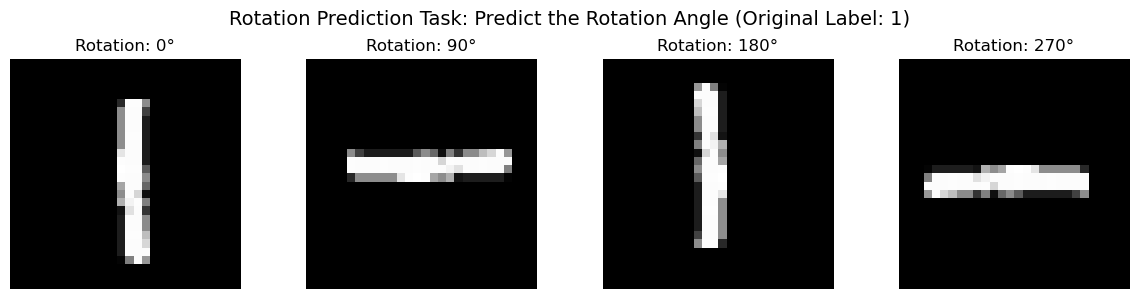

HOW ROTATION PREDICTION WORKS
1. Take an image (any digit).
2. Rotate it randomly by 0°, 90°, 180°, or 270°.
3. The model must predict the rotation angle.
4. The label (rotation angle) comes from the data itself!
5. The model learns features about edges, shapes, and orientation.
6. These features are useful for downstream tasks like classification.


In [7]:
# ## 5. Understanding the SSL Pretext Task: Rotation Prediction
# 
# ### Why Rotation Prediction?
# 
# Rotation prediction is a simple but effective pretext task:
# 
# 1. **Take an image** (e.g., a digit).
# 2. **Rotate it by 0°, 90°, 180°, or 270°**.
# 3. **Task**: Predict the rotation angle.
# 
# ### How Does This Help?
# 
# To predict rotation, the model must learn:
# - What is "up" in an image?
# - What are the edges, shapes, and structures?
# - How to distinguish a rotated digit from the original?
# 
# These features are **useful for downstream tasks** like digit classification!
# 
# ### The Key Insight:
# - The labels (rotation angles) come **from the data itself**.
# - **No human labeling required!**

# %%
# Visualize rotation prediction
def visualize_rotation():
    """Show examples of rotated images."""
    # Select a random image
    idx = np.random.randint(0, len(X_train_full))
    image = X_train_full[idx].reshape(28, 28)
    label = y_train_full[idx]
    
    # Create rotated versions
    rotations = [0, 90, 180, 270]
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    
    for i, angle in enumerate(rotations):
        # Rotate image
        from scipy.ndimage import rotate
        rotated = rotate(image, angle, reshape=False, order=1, mode='constant', cval=0)
        
        axes[i].imshow(rotated, cmap='gray')
        axes[i].set_title(f'Rotation: {angle}°', fontsize=12)
        axes[i].axis('off')
    
    plt.suptitle(f'Rotation Prediction Task: Predict the Rotation Angle (Original Label: {label})', fontsize=14)
    plt.tight_layout()
    plt.savefig('rotation_prediction_task.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_rotation()

print("=" * 60)
print("HOW ROTATION PREDICTION WORKS")
print("=" * 60)
print("1. Take an image (any digit).")
print("2. Rotate it randomly by 0°, 90°, 180°, or 270°.")
print("3. The model must predict the rotation angle.")
print("4. The label (rotation angle) comes from the data itself!")
print("5. The model learns features about edges, shapes, and orientation.")
print("6. These features are useful for downstream tasks like classification.")
print("=" * 60)

In [9]:
# ## 6. Building the SSL Model
# 
# We define a simple neural network for rotation prediction:
# 
# - **Encoder**: A small CNN that takes an image and outputs a feature vector.
# - **Classifier Head**: A linear layer that predicts the rotation angle (4 classes: 0°, 90°, 180°, 270°).
# 
# The encoder will be re-used for the downstream classification task.

# %%
class RotationPredictionModel(nn.Module):
    """
    Neural network for rotation prediction.
    
    The encoder learns useful features by predicting rotation angles.
    The classifier head is used only during pre-training.
    """
    
    def __init__(self, latent_dim=128):
        super(RotationPredictionModel, self).__init__()
        
        # Encoder: Convolutional layers to extract features
        self.encoder = nn.Sequential(
            # Input: 28x28x1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 28x28x32
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 14x14x32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 14x14x64
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 7x7x64
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 7x7x128
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 3x3x128
        )
        
        # Projection to latent space
        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, latent_dim),  # 1152 -> 128
            nn.ReLU(),
        )
        
        # Rotation classifier head (4 classes: 0°, 90°, 180°, 270°)
        self.classifier = nn.Linear(latent_dim, 4)
    
    def forward(self, x):
        """Forward pass through the network."""
        features = self.encoder(x)
        z = self.projection(features)
        rotation_logits = self.classifier(z)
        return rotation_logits, z
    
    def get_encoder(self):
        """Return the encoder part for fine-tuning."""
        return self.encoder

# Initialize the model
model = RotationPredictionModel(latent_dim=128)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 240,772


In [17]:
# ## 7. Data Augmentation for SSL Pre-training
# 
# For SSL pre-training, we apply rotations to create the pretext task.
# 
# ### How It Works:
# 1. We take a batch of images.
# 2. We rotate each image randomly by 0°, 90°, 180°, or 270°.
# 3. The rotation angle becomes the **label** for the pretext task.
# 4. The model learns to predict the rotation angle.

# %%
from scipy.ndimage import rotate

def rotate_batch(images, angles=None):
    """
    Rotate a batch of images by specified angles.
    
    Parameters:
    - images: Batch of images (shape: N, 784 or N, 1, 28, 28)
    - angles: List of angles to rotate by (if None, randomly chosen)
    
    Returns:
    - rotated_images: Rotated images (4D: N, 1, 28, 28)
    - rotation_labels: The angles used (0, 1, 2, 3 for 0°, 90°, 180°, 270°)
    """
    if len(images.shape) == 4:
        # Input is (N, 1, 28, 28)
        N = images.shape[0]
        rotated_batch = []
        labels = []
        
        for i in range(N):
            if angles is None:
                angle_idx = np.random.randint(0, 4)
            else:
                angle_idx = angles[i]
            
            angle = angle_idx * 90
            img = images[i, 0].numpy() if isinstance(images[i, 0], torch.Tensor) else images[i, 0]
            rotated = rotate(img, angle, reshape=False, order=1, mode='constant', cval=0)
            rotated = torch.tensor(rotated, dtype=torch.float32).unsqueeze(0)  # Shape: (1, 28, 28)
            rotated_batch.append(rotated)
            labels.append(angle_idx)
        
        # Stack and return without unsqueezing!
        return torch.stack(rotated_batch), torch.tensor(labels)  # Shape: (N, 1, 28, 28)
    
    else:
        # Input is (N, 784)
        N = images.shape[0]
        rotated_batch = []
        labels = []
        
        for i in range(N):
            if angles is None:
                angle_idx = np.random.randint(0, 4)
            else:
                angle_idx = angles[i]
            
            angle = angle_idx * 90
            img = images[i].reshape(28, 28)
            rotated = rotate(img, angle, reshape=False, order=1, mode='constant', cval=0)
            rotated = rotated.flatten()
            rotated_batch.append(rotated)
            labels.append(angle_idx)
        
        return np.array(rotated_batch), np.array(labels)

In [19]:
# ## 8. Preparing Data for SSL Pre-training
# 
# We convert the unlabeled data to PyTorch tensors and create a DataLoader.

# Convert unlabeled data to PyTorch tensors
X_unlabeled_tensor = torch.tensor(X_unlabeled, dtype=torch.float32)

# Create a DataLoader for SSL pre-training
batch_size = 256
ssl_dataset = TensorDataset(X_unlabeled_tensor)
ssl_loader = DataLoader(ssl_dataset, batch_size=batch_size, shuffle=True)

print(f"SSL pre-training data: {len(X_unlabeled)} samples")
print(f"Number of batches: {len(ssl_loader)}")

# ## 9. SSL Pre-training: Training the Model on Rotation Prediction
# 
# ### What Happens Here?
# 
# 1. We take batches of images from the unlabeled pool.
# 2. We rotate each image randomly (0°, 90°, 180°, or 270°).
# 3. The model predicts the rotation angle.
# 4. We compute the loss (Cross-Entropy) and update weights.
# 
# ### Why This Works:
# - The model learns to recognize patterns in images.
# - It learns what "up" means in a digit.
# - It learns edge detection, shape recognition, and orientation.
# - These features are **general and transferable**.
# 
# ### Important:
# - **No human labels are used!**
# - The model learns entirely from the data.

# %%
def train_ssl(model, data_loader, epochs=10, lr=0.001, device='cpu'):
    """
    Train the SSL model on rotation prediction.
    
    Parameters:
    - model: The neural network
    - data_loader: DataLoader with unlabeled images
    - epochs: Number of training epochs
    - lr: Learning rate
    - device: 'cpu' or 'cuda'
    """
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    train_losses = []
    
    print("=" * 60)
    print("SSL PRE-TRAINING: Rotation Prediction")
    print("=" * 60)
    print(f"Total samples: {len(data_loader.dataset)}")
    print(f"Epochs: {epochs}")
    print(f"Learning rate: {lr}")
    print(f"Device: {device}")
    print("=" * 60)
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for batch_idx, (images,) in enumerate(data_loader):
            # Move to device
            images = images.to(device)
            
            # Rotate images and get rotation labels
            # We rotate images in 4D tensor format (N, 1, 28, 28)
            images_4d = images.view(-1, 1, 28, 28)
            rotated_images, rotation_labels = rotate_batch(images_4d)
            rotated_images = rotated_images.to(device)
            rotation_labels = rotation_labels.to(device)
            
            # Forward pass
            rotation_logits, _ = model(rotated_images)
            
            # Compute loss
            loss = criterion(rotation_logits, rotation_labels)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(data_loader)
        train_losses.append(avg_loss)
        
        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    
    print("SSL pre-training completed!")
    return train_losses

SSL pre-training data: 48900 samples
Number of batches: 192


Using device: cpu

Starting SSL pre-training...
SSL PRE-TRAINING: Rotation Prediction
Total samples: 48900
Epochs: 10
Learning rate: 0.001
Device: cpu
Epoch 2/10, Loss: 0.0847
Epoch 4/10, Loss: 0.0416
Epoch 6/10, Loss: 0.0314
Epoch 8/10, Loss: 0.0413
Epoch 10/10, Loss: 0.0302
SSL pre-training completed!


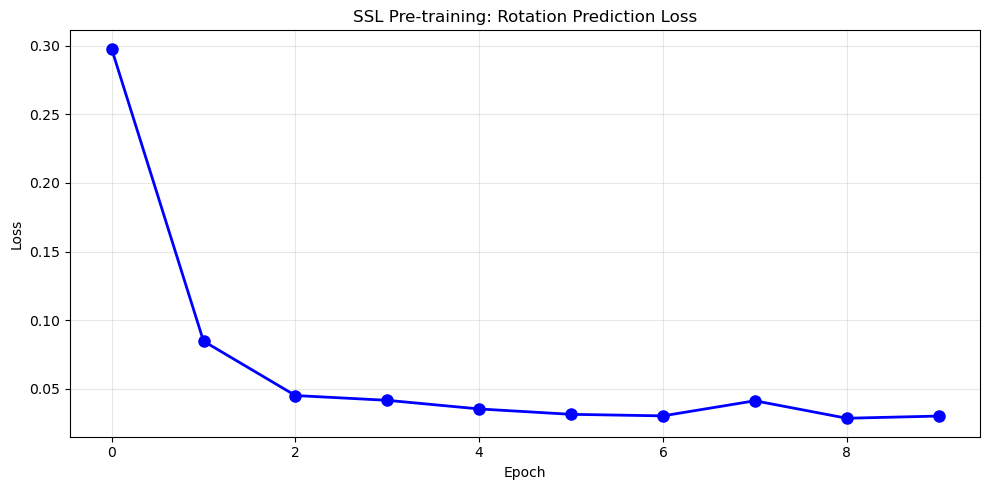

In [21]:
# ## 10. Run SSL Pre-training
# 
# We train the model on rotation prediction using the unlabeled data.

# Device setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Train the SSL model
print("\nStarting SSL pre-training...")
ssl_losses = train_ssl(
    model, ssl_loader, epochs=10, lr=0.001, device=device
)

# Plot training loss
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ssl_losses, 'o-', color='blue', linewidth=2, markersize=8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('SSL Pre-training: Rotation Prediction Loss')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ssl_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ## 11. Understanding What the Model Learned
# 
# ### How SSL Helps:
# 
# The model has now learned features that are useful for predicting rotations:
# - **Edges and shapes**: To know if a digit is rotated, the model must understand its structure.
# - **Orientation**: The model learns what "up" and "down" mean.
# - **Pattern recognition**: The model can identify digits even when rotated.
# 
# ### These features are useful for classification!
# 
# When we fine-tune on a small labeled dataset, the model already has:
# - Knowledge of digit structure.
# - Good initial weights.
# - A "head start" over training from scratch.

# ## 12. Fine-tuning Setup: Preparing the Encoder
# 
# We extract the encoder from the SSL model and prepare it for fine-tuning.

# %%
class SSLClassifier(nn.Module):
    """
    Classifier for fine-tuning on the labeled dataset.
    
    - Uses the pre-trained encoder from SSL.
    - Adds a new classification head (for 10 digits).
    """
    
    def __init__(self, ssl_model, num_classes=10):
        super(SSLClassifier, self).__init__()
        
        # Use the encoder from the SSL model
        self.encoder = ssl_model.encoder
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        features = self.encoder(x)
        logits = self.classifier(features)
        return logits

# Initialize the classifier with the SSL pre-trained encoder
ssl_classifier = SSLClassifier(model, num_classes=10)

print(f"SSL Classifier parameters: {sum(p.numel() for p in ssl_classifier.parameters()):,}")
print(f"Using pre-trained encoder from SSL")

# ## 13. Training from Scratch (Baseline)
# 
# We also train a model **from scratch** (without SSL pre-training) for comparison.
# 
# ### Why We Need This:
# - To see the **benefit** of SSL pre-training.
# - To quantify how much SSL helps with small data.

# %%
class ScratchClassifier(nn.Module):
    """
    Classifier trained from scratch (without SSL pre-training).
    Same architecture as SSLClassifier, but randomly initialized.
    """
    
    def __init__(self, num_classes=10):
        super(ScratchClassifier, self).__init__()
        
        # Same encoder as SSL model (randomly initialized)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        features = self.encoder(x)
        logits = self.classifier(features)
        return logits

# Initialize the scratch classifier
scratch_classifier = ScratchClassifier(num_classes=10)
print(f"Scratch Classifier parameters: {sum(p.numel() for p in scratch_classifier.parameters()):,}")

SSL Classifier parameters: 390,410
Using pre-trained encoder from SSL
Scratch Classifier parameters: 390,410


In [25]:
# ## 14. Fine-tuning on Small Labeled Dataset
# 
# We fine-tune both models on the **small labeled dataset** (100 samples).
def fine_tune_model(model, X_train, y_train, X_test, y_test, 
                    epochs=50, lr=0.001, device='cpu', model_name='Model'):
    """
    Fine-tune a model on a small labeled dataset.
    
    Parameters:
    - model: The classifier to fine-tune
    - X_train: Small labeled features
    - y_train: Small labeled labels
    - X_test: Test features
    - y_test: Test labels
    - epochs: Number of epochs
    - lr: Learning rate
    - device: 'cpu' or 'cuda'
    - model_name: Name for printing
    """
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # Convert data to PyTorch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)
    
    # Reshape for CNN
    X_train_4d = X_train_tensor.view(-1, 1, 28, 28)
    X_test_4d = X_test_tensor.view(-1, 1, 28, 28)
    
    # Create DataLoaders
    train_dataset = TensorDataset(X_train_4d, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=len(X_train), shuffle=True)
    
    train_accs = []
    test_accs = []
    
    print(f"\n{'='*60}")
    print(f"FINE-TUNING: {model_name}")
    print(f"{'='*60}")
    print(f"Training samples: {len(X_train)}")
    print(f"Epochs: {epochs}")
    print(f"Learning rate: {lr}")
    print(f"Device: {device}")
    print(f"{'='*60}")
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        # Evaluate
        model.eval()
        with torch.no_grad():
            # Training accuracy (on the small labeled set)
            train_logits = model(X_train_4d.to(device))
            train_preds = torch.argmax(train_logits, dim=1)
            train_acc = accuracy_score(y_train, train_preds.cpu().numpy())
            
            # Test accuracy
            test_logits = model(X_test_4d.to(device))
            test_preds = torch.argmax(test_logits, dim=1)
            test_acc = accuracy_score(y_test, test_preds.cpu().numpy())
        
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")
    
    print(f"Final Test Accuracy: {test_accs[-1]:.4f}")
    
    return train_accs, test_accs

In [27]:
# ## 15. Run Fine-tuning: SSL vs Scratch
# 
# We fine-tune both models and compare their performance.

# %%
# Fine-tune the SSL pre-trained model
ssl_train_accs, ssl_test_accs = fine_tune_model(
    ssl_classifier, X_labeled, y_labeled, X_test, y_test,
    epochs=50, lr=0.001, device=device, model_name='SSL Pre-trained'
)

print("\n" + "=" * 60)

# Fine-tune the scratch model
scratch_train_accs, scratch_test_accs = fine_tune_model(
    scratch_classifier, X_labeled, y_labeled, X_test, y_test,
    epochs=50, lr=0.001, device=device, model_name='From Scratch'
)


FINE-TUNING: SSL Pre-trained
Training samples: 100
Epochs: 50
Learning rate: 0.001
Device: cpu
Epoch 10/50, Train Acc: 0.8200, Test Acc: 0.7105
Epoch 20/50, Train Acc: 0.9700, Test Acc: 0.8258
Epoch 30/50, Train Acc: 1.0000, Test Acc: 0.8474
Epoch 40/50, Train Acc: 1.0000, Test Acc: 0.8549
Epoch 50/50, Train Acc: 1.0000, Test Acc: 0.8624
Final Test Accuracy: 0.8624


FINE-TUNING: From Scratch
Training samples: 100
Epochs: 50
Learning rate: 0.001
Device: cpu
Epoch 10/50, Train Acc: 0.7000, Test Acc: 0.6218
Epoch 20/50, Train Acc: 0.8200, Test Acc: 0.7170
Epoch 30/50, Train Acc: 0.9200, Test Acc: 0.7795
Epoch 40/50, Train Acc: 0.9800, Test Acc: 0.8260
Epoch 50/50, Train Acc: 1.0000, Test Acc: 0.8390
Final Test Accuracy: 0.8390


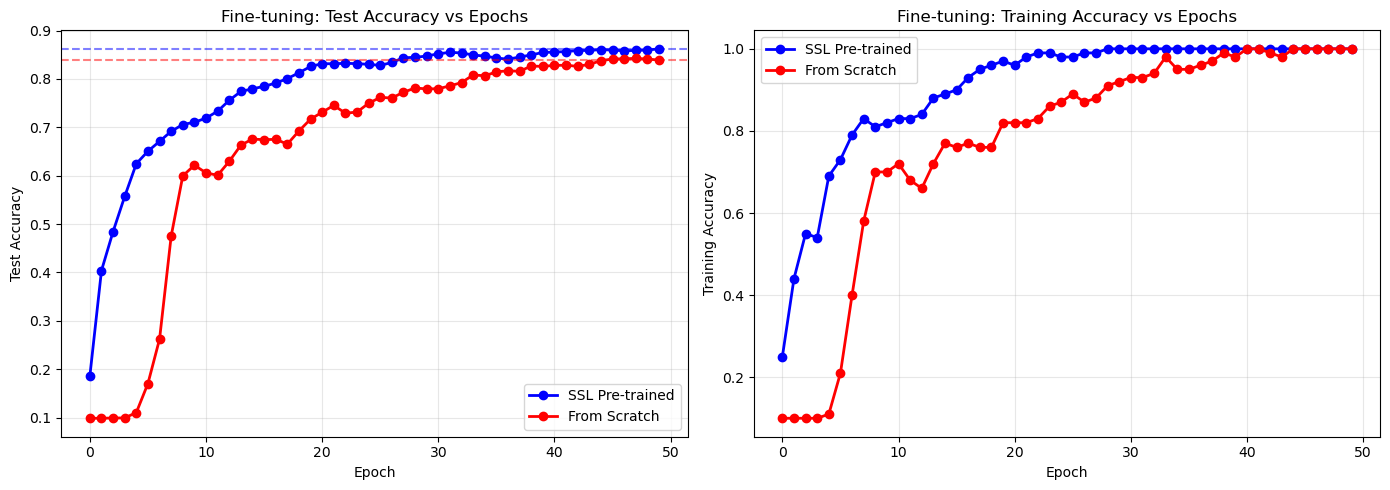

FINAL RESULTS SUMMARY
Method               Test Accuracy   Improvement    
------------------------------------------------------------
SSL Pre-trained      0.8624     +0.0233
From Scratch         0.8390     -

KEY INSIGHTS
1. SSL pre-training improved test accuracy by 2.3 percentage points.
2. With only 100 labeled samples, SSL achieved 86.2% accuracy.
3. Training from scratch on 100 samples achieved only 83.9% accuracy.
4. The SSL model converged faster and reached higher accuracy.
5. This demonstrates the power of SSL: using abundant unlabeled data to learn useful features.


In [29]:
# ## 16. Compare Results: SSL vs Baseline

# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Test accuracy over epochs
ax1 = axes[0]
ax1.plot(ssl_test_accs, 'o-', color='blue', linewidth=2, markersize=6, label='SSL Pre-trained')
ax1.plot(scratch_test_accs, 'o-', color='red', linewidth=2, markersize=6, label='From Scratch')
ax1.axhline(y=ssl_test_accs[-1], color='blue', linestyle='--', alpha=0.5)
ax1.axhline(y=scratch_test_accs[-1], color='red', linestyle='--', alpha=0.5)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Fine-tuning: Test Accuracy vs Epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Training accuracy over epochs
ax2 = axes[1]
ax2.plot(ssl_train_accs, 'o-', color='blue', linewidth=2, markersize=6, label='SSL Pre-trained')
ax2.plot(scratch_train_accs, 'o-', color='red', linewidth=2, markersize=6, label='From Scratch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Training Accuracy')
ax2.set_title('Fine-tuning: Training Accuracy vs Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ssl_finetuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 17. Results Summary

# %%
# Print final results
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"{'Method':<20} {'Test Accuracy':<15} {'Improvement':<15}")
print("-" * 60)

ssl_final_acc = ssl_test_accs[-1]
scratch_final_acc = scratch_test_accs[-1]
improvement = ssl_final_acc - scratch_final_acc

print(f"{'SSL Pre-trained':<20} {ssl_final_acc:.4f}     +{improvement:.4f}")
print(f"{'From Scratch':<20} {scratch_final_acc:.4f}     -")

print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)
print(f"1. SSL pre-training improved test accuracy by {improvement*100:.1f} percentage points.")
print(f"2. With only {len(X_labeled)} labeled samples, SSL achieved {ssl_final_acc*100:.1f}% accuracy.")
print(f"3. Training from scratch on {len(X_labeled)} samples achieved only {scratch_final_acc*100:.1f}% accuracy.")
print(f"4. The SSL model converged faster and reached higher accuracy.")
print(f"5. This demonstrates the power of SSL: using abundant unlabeled data to learn useful features.")